# 0.3 Censo 2024 → manzanas de la zona

Versión paramétrica de `censo2024_processing.ipynb`. Misma lógica exacta del paper
(mismas features `pct_`, mismas columnas de salida), pero el filtro geográfico deja
de estar fijo en Peñalolén y usa la lista `COMUNAS` de `config.py`.

**Entrada:** `CENSO_2024/Cartografía_censo2024_R13_Manzanas.parquet` (66.873 manzanas, R13 completa, fuera del repo)

**Salida:** `data/processed/manzanas_{zona}_paper.parquet`

Con `ZONA='penalolen'` reproduce byte a byte el archivo del paper. El original
`censo2024_processing.ipynb` se conserva intacto como respaldo.

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from config import ZONA, COMUNAS, FP_CENSO_MANZANAS, FP_MANZ_PAPER

import geopandas as gpd
import numpy as np

print(f'Zona: {ZONA} | comunas: {COMUNAS}')

Zona: suroriente | comunas: [13110, 13113, 13118, 13120, 13122]


## 1. Cargar manzanas R13 y filtrar por zona

In [2]:
manzanas = gpd.read_parquet(FP_CENSO_MANZANAS)
print(f'Manzanas R13 completas: {manzanas.shape}')

# Filtro paramétrico: por CUT (numérico) en vez de COMUNA string fija
manz = manzanas[manzanas['CUT'].isin(COMUNAS)].copy()
manz = manz[manz['n_per'].fillna(0) > 0].copy()

print(f'Manzanas de la zona (n_per>0): {manz.shape}')
print(manz.groupby('COMUNA').size().sort_values(ascending=False).to_string())

Manzanas R13 completas: (66873, 218)
Manzanas de la zona (n_per>0): (6782, 218)
COMUNA
LA FLORIDA    2796
PEÑALOLÉN     1629
ÑUÑOA          973
MACUL          776
LA REINA       608


## 2. Selección de columnas (idéntico al paper)

In [3]:
id_cols = ['CUT', 'COMUNA', 'COD_ZONA', 'MANZENT', 'COD_MANZANA', 'SHAPE']
demo_cols = ['n_per', 'n_hombres', 'n_mujeres', 'n_edad_60_mas', 'prom_edad']
vuln_cols = ['n_discapacidad', 'n_dificultad_mover', 'n_hog_unipersonales', 'n_hog_60']
edu_cols  = ['prom_escolaridad18', 'n_cine_primaria', 'n_cine_secundaria',
             'n_cine_terciaria_maestria_doctorado', 'n_analfabet']
mob_cols  = ['n_transporte_camina', 'n_transporte_publico', 'n_transporte_auto']
housing_cols = ['n_viv_hacinadas', 'n_hog_allegados', 'n_mat_paredes_precarios',
                'n_mat_techo_precarios', 'n_mat_piso_tierra', 'n_serv_hig_no_tiene']

keep_cols = id_cols + demo_cols + vuln_cols + edu_cols + mob_cols + housing_cols
manz = manz[keep_cols].copy()

## 3. Features de proporción (idéntico al paper)

In [4]:
def safe_div(num, den):
    return np.where((den.notna()) & (den > 0), num / den, np.nan)

manz['pct_60mas']       = safe_div(manz['n_edad_60_mas'], manz['n_per'])
manz['pct_discapacidad'] = safe_div(manz['n_discapacidad'], manz['n_per'])
manz['pct_dif_mover']   = safe_div(manz['n_dificultad_mover'], manz['n_per'])
manz['pct_hog_unip']    = safe_div(manz['n_hog_unipersonales'], manz['n_hog_60'] + manz['n_hog_unipersonales'])
manz['pct_hog_60']      = safe_div(manz['n_hog_60'], manz['n_hog_unipersonales'] + manz['n_hog_60'])

manz['pct_primaria']    = safe_div(manz['n_cine_primaria'], manz['n_per'])
manz['pct_secundaria']  = safe_div(manz['n_cine_secundaria'], manz['n_per'])
manz['pct_terciaria']   = safe_div(manz['n_cine_terciaria_maestria_doctorado'], manz['n_per'])
manz['pct_analfabet']   = safe_div(manz['n_analfabet'], manz['n_per'])

manz['pct_camina']      = safe_div(manz['n_transporte_camina'], manz['n_per'])
manz['pct_tp']          = safe_div(manz['n_transporte_publico'], manz['n_per'])
manz['pct_auto']        = safe_div(manz['n_transporte_auto'], manz['n_per'])

manz['pct_hacinamiento'] = safe_div(manz['n_viv_hacinadas'], manz['n_per'])
manz['pct_allegados']   = safe_div(manz['n_hog_allegados'], manz['n_per'])
manz['pct_precar_pared'] = safe_div(manz['n_mat_paredes_precarios'], manz['n_per'])
manz['pct_precar_techo'] = safe_div(manz['n_mat_techo_precarios'], manz['n_per'])
manz['pct_piso_tierra'] = safe_div(manz['n_mat_piso_tierra'], manz['n_per'])
manz['pct_sin_sanit']   = safe_div(manz['n_serv_hig_no_tiene'], manz['n_per'])

## 4. Columnas finales del paper y export

In [5]:
paper_cols = [
    'CUT', 'COMUNA', 'COD_ZONA', 'MANZENT', 'COD_MANZANA', 'SHAPE',
    'n_per', 'n_edad_60_mas', 'prom_edad', 'prom_escolaridad18',
    'pct_60mas', 'pct_discapacidad', 'pct_dif_mover',
    'pct_analfabet', 'pct_terciaria',
    'pct_camina',
    'pct_hacinamiento', 'pct_allegados',
    'pct_precar_pared', 'pct_precar_techo', 'pct_piso_tierra', 'pct_sin_sanit',
]
manz_paper = manz[paper_cols].copy()

print(f'Shape final: {manz_paper.shape}')
print(f'NaN por columna (top): \n{manz_paper.isna().mean().sort_values(ascending=False).head(5)}')

Shape final: (6782, 22)
NaN por columna (top): 
prom_escolaridad18    0.000295
CUT                   0.000000
pct_dif_mover         0.000000
pct_piso_tierra       0.000000
pct_precar_techo      0.000000
dtype: float64


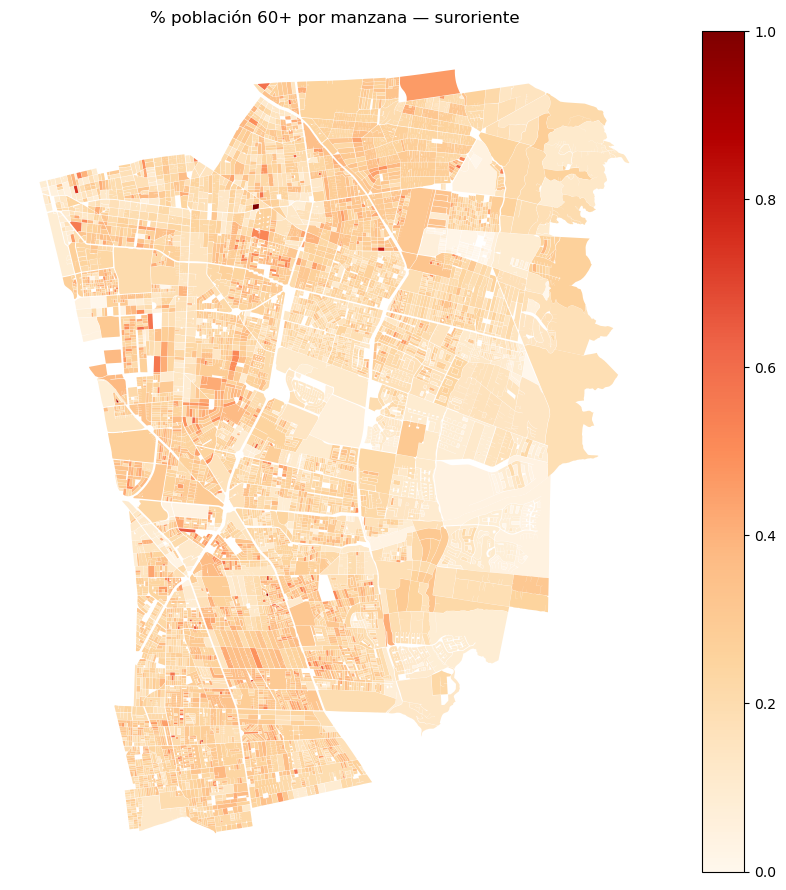

In [6]:
import matplotlib.pyplot as plt

ax = manz_paper.set_geometry('SHAPE').plot(column='pct_60mas', figsize=(9, 9),
                                           legend=True, cmap='OrRd')
ax.set_title(f'% población 60+ por manzana — {ZONA}')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [7]:
FP_MANZ_PAPER.parent.mkdir(parents=True, exist_ok=True)
manz_paper.to_parquet(FP_MANZ_PAPER)
manz_paper.set_geometry('SHAPE').to_file(FP_MANZ_PAPER.with_suffix('.gpkg'), driver='GPKG')
print(f'Guardado: {FP_MANZ_PAPER}')
print(f'         {FP_MANZ_PAPER.with_suffix(".gpkg")}')

Guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\manzanas_suroriente_paper.parquet
         C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\manzanas_suroriente_paper.gpkg
